# PFA v4 — Partie 1 : climat × blé CBOT (`ZW=F`)

**Objectif :** étudier une relation **mensuelle** (faible ou nulle attendue) entre  
les **rendements du blé** à terme et deux signaux climatiques :
- **GISS** : anomalie de température moyennée sur une **boîte Great Plains** (approx. culture blé US)  
- **SPEI** : indice **USA** (humidité / sécheresse vs climat)

**Données :** `dataSets/v4/` (`wheat_monthly_returns.csv`, `gistemp250_GHCNv4.csv`, `spei_usa.csv`).  
Exécuter le notebook depuis le dossier **`MLStudy2`**.

**Note :** la partie 2 (production → prix) pourra utiliser d’autres fichiers dans `v4`.

## 0. Imports et boîte géographique (Great Plains)

Boîte **grossière** orientée **Plaines** (hiver / printemps US), pas exclusive du blé :
- **Latitude** 35°N – 49°N  
- **Longitude** −110° – −95° (convention −180…180)

À documenter telle quelle dans le rapport : compromis grille GISS ~2°.

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    r2_score,
)

BASE = Path.cwd()
V4 = BASE / "dataSets" / "v4"
WHEAT_PATH = V4 / "wheat_monthly_returns.csv"
GISS_PATH = V4 / "gistemp250_GHCNv4.csv"
SPEI_PATH = V4 / "spei_usa.csv"
PROD_PATH = V4 / "american_wheat_production.csv"

CHUNKSIZE = 1_000_000
# Great Plains (approx. blé US)
LAT_MIN, LAT_MAX = 35.0, 49.0
LON_MIN, LON_MAX = -110.0, -95.0

for p in (WHEAT_PATH, GISS_PATH, SPEI_PATH, PROD_PATH):
    assert p.exists(), f"Manquant : {p} — cd MLStudy2 et vérifier dataSets/v4"

## 1. Rendements mensuels du blé (`ZW=F`)

Deuxième ligne = ticker Yahoo ; dates en **début de mois** `Month` pour aligner GISS / SPEI.

In [11]:
wheat = pd.read_csv(WHEAT_PATH, skiprows=[1])
wheat["Date"] = pd.to_datetime(wheat["Date"], errors="coerce")
wheat = wheat.dropna(subset=["Date"])
wheat["Month"] = wheat["Date"].dt.to_period("M").dt.to_timestamp()
wheat = wheat[["Month", "Close", "Monthly_Return"]].sort_values("Month").reset_index(
    drop=True
)
wheat["Target_up"] = (wheat["Monthly_Return"] > 0).astype(int)
print(wheat.head())
print("…")
print(wheat.tail())
print("n =", len(wheat))

       Month   Close  Monthly_Return  Target_up
0 2000-08-01  251.00        0.020325          1
1 2000-09-01  258.00        0.027888          1
2 2000-10-01  253.50       -0.017442          0
3 2000-11-01  252.50       -0.003945          0
4 2000-12-01  272.75        0.080198          1
…
         Month   Close  Monthly_Return  Target_up
304 2025-12-01  507.00       -0.045198          0
305 2026-01-01  538.00        0.061144          1
306 2026-02-01  591.25        0.098978          1
307 2026-03-01  616.25        0.042283          1
308 2026-04-01  597.75       -0.030020          0
n = 309


## 2. GISS — moyenne mensuelle sur la boîte Plaines

Lecture **chunkée** du gros CSV ; pour chaque mois : moyenne des anomalies `tempanomaly_degC` dans la boîte → `temp_plains_mean`.

In [12]:
def giss_plains_monthly_mean(csv_path: Path, chunksize: int) -> pd.DataFrame:
    parts: list[pd.DataFrame] = []
    for chunk in pd.read_csv(csv_path, chunksize=chunksize):
        chunk = chunk.dropna(subset=["tempanomaly_degC", "time"])
        if chunk.empty:
            continue
        sel = chunk[
            (chunk["lat"] >= LAT_MIN)
            & (chunk["lat"] <= LAT_MAX)
            & (chunk["lon"] >= LON_MIN)
            & (chunk["lon"] <= LON_MAX)
        ]
        if sel.empty:
            continue
        parts.append(
            sel.groupby("time", sort=False)["tempanomaly_degC"].agg(["sum", "count"])
        )
    if not parts:
        return pd.DataFrame(columns=["Month", "temp_plains_mean"])
    agg = pd.concat(parts).groupby(level=0).sum()
    plains_mean = agg["sum"] / agg["count"]
    out = plains_mean.rename("temp_plains_mean").reset_index()
    out["Month"] = pd.to_datetime(
        out["time"].astype(str).str.strip() + "-01", errors="coerce"
    )
    return out.drop(columns=["time"]).dropna(subset=["Month"])


giss_monthly = giss_plains_monthly_mean(GISS_PATH, CHUNKSIZE)
print(giss_monthly.head(3))
print("…")
print(giss_monthly.tail(3))
print("n =", len(giss_monthly))

   temp_plains_mean      Month
0          3.486393 1880-01-01
1         -1.167213 1880-02-01
2         -2.461639 1880-03-01
…
      temp_plains_mean      Month
1751          3.178594 2025-12-01
1752          3.233281 2026-01-01
1753          5.621562 2026-02-01
n = 1754


## 3. Fusion blé × GISS × SPEI

**Inner join** sur `Month` : même calendrier partout.

In [13]:
spei = pd.read_csv(SPEI_PATH)
spei["Month"] = pd.to_datetime(spei["time"], errors="coerce").dt.to_period("M").dt.to_timestamp()
spei = spei[["Month", "spei"]].dropna(subset=["Month"]).drop_duplicates(
    subset=["Month"], keep="last"
)

df = (
    wheat.merge(giss_monthly, on="Month", how="inner")
    .merge(spei, on="Month", how="inner")
    .sort_values("Month")
    .reset_index(drop=True)
)
print("Shape :", df.shape)
print("De", df["Month"].min().date(), "à", df["Month"].max().date())
df.head(8)

Shape : (304, 6)
De 2000-08-01 à 2025-11-01


,Month,Close,Monthly_Return,Target_up,temp_plains_mean,spei
0,2000-08-01,251.00,0.020325,1,1.844375,-0.417125
1,2000-09-01,258.00,0.027888,1,1.078750,-0.252058
2,2000-10-01,253.50,-0.017442,0,0.692969,0.063593
3,2000-11-01,252.50,-0.003945,0,-3.277969,0.447560
4,2000-12-01,272.75,0.080198,1,-3.604062,-0.194191
5,2001-01-01,271.00,-0.006416,0,3.104687,-0.141174
6,2001-02-01,257.50,-0.049815,0,-1.848906,0.270554
7,2001-03-01,265.00,0.029126,1,1.088750,-0.064330


### Partie 1 — prix blé et anomalie GISS (double échelle)

Même principe que **S&P × GISS** / **maïs v3** : **clôture ZW=F** (gauche) et **anomalie GISS Plaines** (droite), sur la **période commune** après fusion.

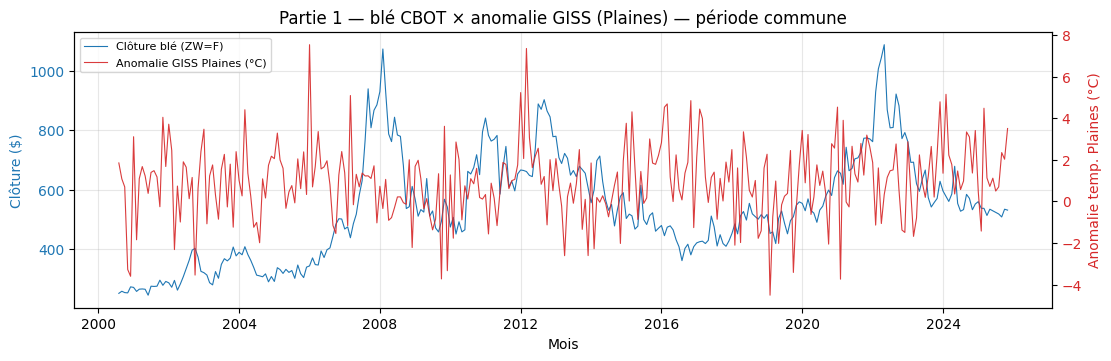

In [14]:
fig, ax_l = plt.subplots(figsize=(11, 3.5), layout="constrained")
ax_r = ax_l.twinx()
ax_l.plot(df["Month"], df["Close"], color="#1f77b4", lw=0.8, label="Clôture blé (ZW=F)")
ax_r.plot(
    df["Month"],
    df["temp_plains_mean"],
    color="#d62728",
    lw=0.8,
    alpha=0.9,
    label="Anomalie GISS Plaines (°C)",
)
ax_l.set_xlabel("Mois")
ax_l.set_ylabel("Clôture ($)", color="#1f77b4")
ax_r.set_ylabel("Anomalie temp. Plaines (°C)", color="#d62728")
ax_l.tick_params(axis="y", labelcolor="#1f77b4")
ax_r.tick_params(axis="y", labelcolor="#d62728")
ax_l.set_title("Partie 1 — blé CBOT × anomalie GISS (Plaines) — période commune")
lines_l, lab_l = ax_l.get_legend_handles_labels()
lines_r, lab_r = ax_r.get_legend_handles_labels()
ax_l.legend(lines_l + lines_r, lab_l + lab_r, loc="upper left", fontsize=8)
ax_l.grid(True, alpha=0.3)
plt.show()

## 4. EDA — séries et corrélations

Le blé à terme dépend du **monde entier** (Russie, UE, météo ailleurs, macro). Les corrélations brutes sont souvent **faibles**.

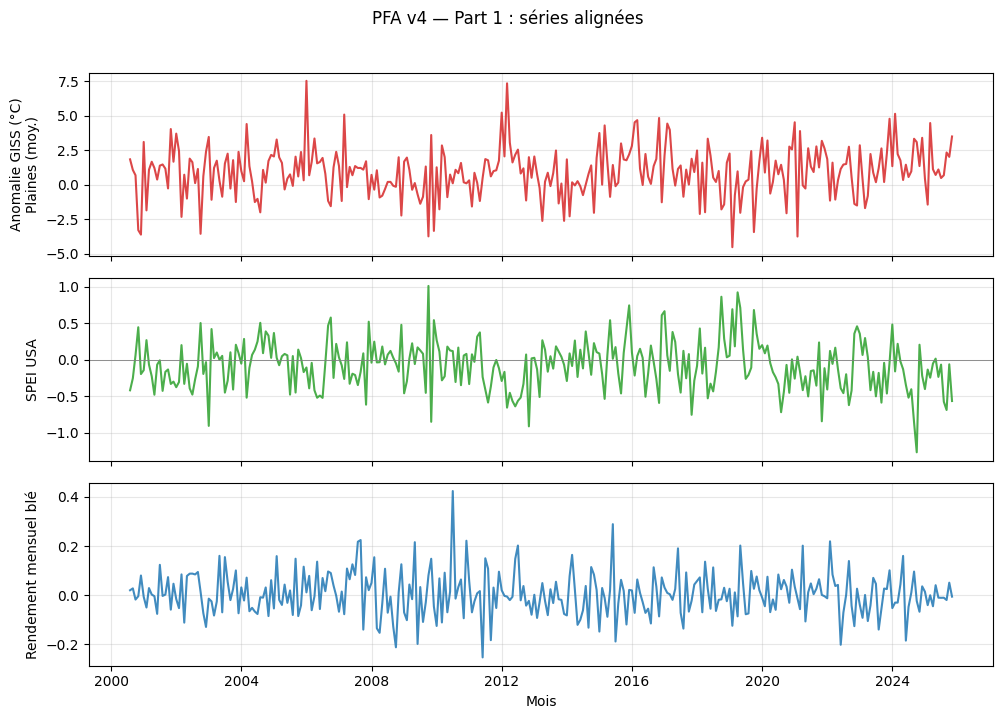

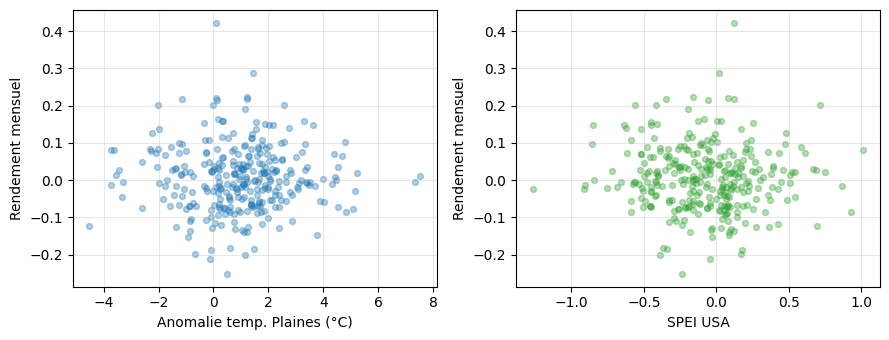

Corr. Pearson (temp Plaines, rendement) = -0.0038
Corr. Pearson (SPEI, rendement)         = -0.0480
Corr. (temp Plaines, SPEI)             = -0.5245


In [15]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].plot(df["Month"], df["temp_plains_mean"], color="tab:red", alpha=0.85)
axes[0].set_ylabel("Anomalie GISS (°C)\nPlaines (moy.)")
axes[0].grid(True, alpha=0.3)
axes[1].plot(df["Month"], df["spei"], color="tab:green", alpha=0.85)
axes[1].set_ylabel("SPEI USA")
axes[1].axhline(0, color="gray", lw=0.6)
axes[1].grid(True, alpha=0.3)
axes[2].plot(df["Month"], df["Monthly_Return"], color="tab:blue", alpha=0.85)
axes[2].set_ylabel("Rendement mensuel blé")
axes[2].set_xlabel("Mois")
axes[2].grid(True, alpha=0.3)
fig.suptitle("PFA v4 — Part 1 : séries alignées", y=1.02)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
ax[0].scatter(df["temp_plains_mean"], df["Monthly_Return"], alpha=0.35, s=18)
ax[0].set_xlabel("Anomalie temp. Plaines (°C)")
ax[0].set_ylabel("Rendement mensuel")
ax[0].grid(True, alpha=0.3)
ax[1].scatter(df["spei"], df["Monthly_Return"], alpha=0.35, s=18, color="tab:green")
ax[1].set_xlabel("SPEI USA")
ax[1].set_ylabel("Rendement mensuel")
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

r_t = df["temp_plains_mean"].corr(df["Monthly_Return"])
r_s = df["spei"].corr(df["Monthly_Return"])
r_ts = df["temp_plains_mean"].corr(df["spei"])
print(f"Corr. Pearson (temp Plaines, rendement) = {r_t:.4f}")
print(f"Corr. Pearson (SPEI, rendement)         = {r_s:.4f}")
print(f"Corr. (temp Plaines, SPEI)             = {r_ts:.4f}")

## 5. Modèles simples (lags, split chronologique)

**Features :** `temp_l1`, `temp_l2`, `spei_l1`, `spei_l2` (pas de mois courant).  
**Train / test :** 80 % / 20 % des mois dans l’ordre du temps.

In [16]:
m = df.copy()
m["temp_l1"] = m["temp_plains_mean"].shift(1)
m["temp_l2"] = m["temp_plains_mean"].shift(2)
m["spei_l1"] = m["spei"].shift(1)
m["spei_l2"] = m["spei"].shift(2)
m = m.dropna().reset_index(drop=True)

feat_cols = ["temp_l1", "temp_l2", "spei_l1", "spei_l2"]
X = m[feat_cols]
y_ret = m["Monthly_Return"]
y_up = m["Target_up"]

split = int(len(m) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
yret_train, yret_test = y_ret.iloc[:split], y_ret.iloc[split:]
yup_train, yup_test = y_up.iloc[:split], y_up.iloc[split:]

print(f"Train : {len(X_train)} mois | Test : {len(X_test)} mois")
print(f"Test : {m['Month'].iloc[split].date()} → {m['Month'].iloc[-1].date()}")

reg = LinearRegression().fit(X_train, yret_train)
pred_ret = reg.predict(X_test)
print("\n--- Régression (rendement continu) ---")
print(f"R² test  : {r2_score(yret_test, pred_ret):.4f}")
print(f"MAE test : {mean_absolute_error(yret_test, pred_ret):.6f}")
print("Coefficients :", dict(zip(feat_cols, reg.coef_)))

clf = LogisticRegression(max_iter=500).fit(X_train, yup_train)
pred_up = clf.predict(X_test)
acc_model = accuracy_score(yup_test, pred_up)

maj_train = int(yup_train.mode().iloc[0])
base_cls = np.full(shape=len(yup_test), fill_value=maj_train, dtype=int)
acc_baseline = accuracy_score(yup_test, base_cls)

print("\n--- Classification mois > 0 (test) ---")
print(f"Baseline accuracy : {acc_baseline:.4f}  (toujours la classe majoritaire du train = {maj_train})")
print(f"Modèle test       : {acc_model:.4f}  (régression logistique, GISS + SPEI en lags)")
print(f"F1 (classe 1)     : {f1_score(yup_test, pred_up, zero_division=0):.4f}")
print(classification_report(yup_test, pred_up, digits=3, zero_division=0))

print("\n--- Conclusion (Partie 1, test) ---")
delta_pp = (acc_model - acc_baseline) * 100  # points de pourcentage
if delta_pp > 2:
    print(f"Le modèle dépasse la baseline de ~{delta_pp:.1f} pts → léger gain out-of-sample (à interpréter prudemment).")
elif delta_pp < -2:
    print(f"Le modèle est sous la baseline de ~{-delta_pp:.1f} pts → pas d’apport net des features climat sur ce split.")
else:
    print("Modèle et baseline sont proches → pas de preuve claire d’un mieux grâce au climat sur cette fenêtre de test.")

Train : 241 mois | Test : 61 mois
Test : 2020-11-01 → 2025-11-01

--- Régression (rendement continu) ---
R² test  : 0.0388
MAE test : 0.057020
Coefficients : {'temp_l1': np.float64(0.0065898648022578625), 'temp_l2': np.float64(-0.003990662424155867), 'spei_l1': np.float64(0.038388216169050686), 'spei_l2': np.float64(-0.04509408183018685)}

--- Classification mois > 0 (test) ---
Baseline accuracy : 0.4918  (toujours la classe majoritaire du train = 1)
Modèle test       : 0.6230  (régression logistique, GISS + SPEI en lags)
F1 (classe 1)     : 0.6349
              precision    recall  f1-score   support

           0      0.643     0.581     0.610        31
           1      0.606     0.667     0.635        30

    accuracy                          0.623        61
   macro avg      0.624     0.624     0.623        61
weighted avg      0.625     0.623     0.622        61


--- Conclusion (Partie 1, test) ---
Le modèle dépasse la baseline de ~13.1 pts → léger gain out-of-sample (à interpré

### Partie 1 — graphique des résultats (classification mensuelle)

Même **split 80/20** chronologique que la cellule des modèles. **Baseline** : lags **GISS** seuls ; **enrichi** : lags GISS **+ SPEI**. **Ligne pointillée** : prédire toujours « hausse » sur le test. Modèles : **régression logistique** et **forêt aléatoire** (comme `PFA_pipeline.ipynb`).

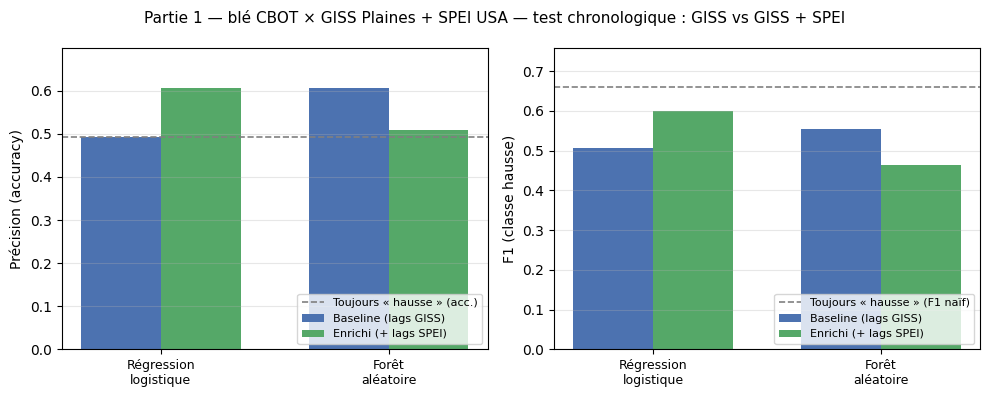

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    _ = m.shape
    _ = split
except NameError as e:
    raise RuntimeError(
        "Exécuter d'abord la cellule Partie 1 qui construit m, les lags et split."
    ) from e

feat_temp = ["temp_l1", "temp_l2"]
feat_all = ["temp_l1", "temp_l2", "spei_l1", "spei_l2"]
X_tr_m = m[feat_temp].iloc[:split]
X_te_m = m[feat_temp].iloc[split:]
X_tr_a = m[feat_all].iloc[:split]
X_te_a = m[feat_all].iloc[split:]
y_tr = m["Target_up"].iloc[:split]
y_te = m["Target_up"].iloc[split:]


def make_lr():
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=42,
                    solver="lbfgs",
                ),
            ),
        ]
    )


def make_rf():
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )


def _test_scores(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    if hasattr(model, "predict_proba"):
        proba1 = model.predict_proba(X_test)[:, 1]
        y_pred = (proba1 >= 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    return acc, f1


model_specs = [
    ("Régression logistique", make_lr),
    ("Forêt aléatoire", make_rf),
]
acc_base, acc_enr, f1_base, f1_enr = [], [], [], []
for _label, factory in model_specs:
    ab, fb = _test_scores(factory(), X_tr_m, X_te_m, y_tr, y_te)
    ae, fe = _test_scores(factory(), X_tr_a, X_te_a, y_tr, y_te)
    acc_base.append(ab)
    acc_enr.append(ae)
    f1_base.append(fb)
    f1_enr.append(fe)

x = np.arange(len(model_specs))
width = 0.35
p_up_test = float(y_te.mean())
acc_naive_up = p_up_test
f1_naive_up = (2 * p_up_test / (1 + p_up_test)) if p_up_test > 0 else 0.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
configs = [
    (acc_base, acc_enr, "Précision (accuracy)", acc_naive_up, "Toujours « hausse » (acc.)"),
    (f1_base, f1_enr, "F1 (classe hausse)", f1_naive_up, "Toujours « hausse » (F1 naïf)"),
]
for ax, (base, enr, title, ref_line, ref_label) in zip(axes, configs):
    ax.bar(x - width / 2, base, width, label="Baseline (lags GISS)", color="#4C72B0")
    ax.bar(x + width / 2, enr, width, label="Enrichi (+ lags SPEI)", color="#55A868")
    ax.axhline(ref_line, color="gray", linestyle="--", linewidth=1.2, label=ref_label)
    ax.set_xticks(x)
    ax.set_xticklabels([m_[0].replace(" ", "\n") for m_ in model_specs], fontsize=9)
    ax.set_ylabel(title)
    top = max(ref_line, *base, *enr)
    ax.set_ylim(0, min(1.05, top * 1.12 + 0.02))
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    "Partie 1 — blé CBOT × GISS Plaines + SPEI USA — test chronologique : GISS vs GISS + SPEI",
    fontsize=11,
)
fig.tight_layout()
plt.show()

## Synthèse — Partie 1 (oral / rapport)

- **Baseline accuracy** : prédire pour **chaque** mois de test la classe **la plus fréquente dans le train** (sans climat). C’est le minimum pour dire qu’un modèle « apporte quelque chose ».
- **Modèle test** : même échantillon de test, avec **température Plaines + SPEI** en **lags** (pas de fuite du mois courant).

**En conclusion :** si les deux accuracies sont **quasi identiques**, la Partie 1 montre qu’avec cette spec (mensuel, boîte GISS grossière, SPEI USA), le climat **n’améliore pas** de façon robuste la prédiction du **signe** du rendement blé — ce qui **motive la Partie 2** (liaison climat → **production** puis rapport aux prix). Si le modèle dépasse nettement la baseline, vous le citez avec prudence (petit test, corrélation temp/SPEI).

## Partie 2 — Climat (GISS Plain + SPEI) ↔ **production** blé USA

**Données production :** `american_wheat_production.csv` (colonnes filtrées `Country == USA`, `Item == Wheat`). Série **annuelle** importée telle quelle pour ce POC.

**Climat agrégé :** pour chaque **année calendaire**, moyennes **mai–septembre** sur la même boîte Plain que la Partie 1 (`temp_plains_mean`) et sur **SPEI USA**.

**Lag (convention du notebook) :** la météo **mai–sep de l’année Y−1** est associée à la **production de l’année Y** (approximation narrative ; la campagne marketing réelle peut différer).

**Lecture pour un public non technique :** la cellule de code affiche des **pourcentages** (erreur moyenne rapportée à la production, gain vs un scénario « sans climat ») et **trois figures** : (1) production vs température et vs SPEI avec ligne de tendance ; (2) barres comparant deux méthodes sur la période de test ; (3) plus les points sont près de la diagonale, plus les prédictions sont proches du réel.

**Prérequis :** exécuter les cellules **jusqu’à la construction de `giss_monthly`** (§2).

Panel annuel (production × climat lag) : (65, 4)
Années : 1961 → 2025
   Year  production_t  temp_gs_mean  spei_gs_mean
0  1961       1000000      0.192156     -0.060640
1  1962       1020000     -0.219969      0.170649
2  1963       1040000     -0.252875      0.142231
…
    Year  production_t  temp_gs_mean  spei_gs_mean
62  2023       2240000      1.441562     -0.357845
63  2024       2260000      1.427750     -0.368646
64  2025       2280000      1.337344     -0.449322

--- Associations sur tout l’historique (indicateur de tendance commune, pas de causalité) ---
Température (mai–sep, année précédente) vs production : coefficient r = 0.55
  → en langage simple : alignement « en ligne droite » ≈ 55 % du maximum possible (100 % = points sur une droite parfaite).
SPEI vs production : r = -0.66  → ≈ 66 % du maximum (même lecture).


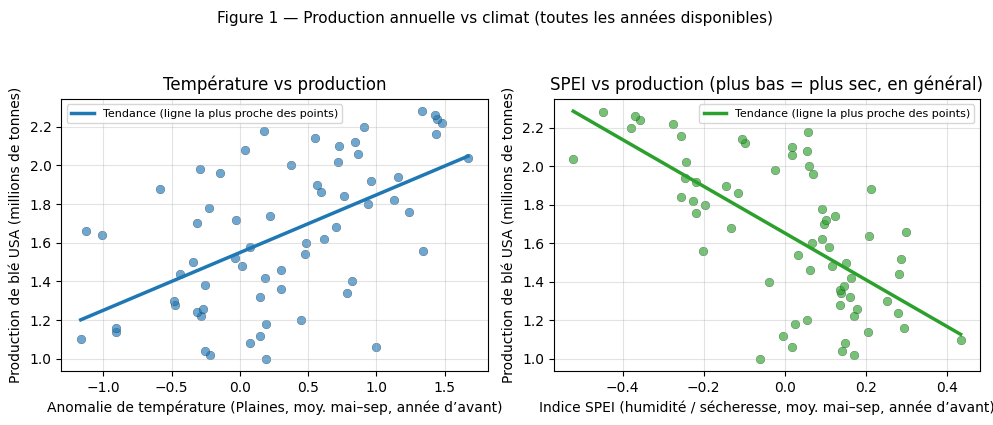


--- Découpage temporel (comme un « examen sur le futur ») ---
Années pour construire le modèle : 52 (80 % du tableau), période de test : 13 années (20 %), soit 2013–2025.

--- Erreur moyenne sur la période de test (en tonnes puis en %) ---
Avec température + SPEI : erreur moyenne = 408,421 t 
  → soit ≈ 18.9 % de la production moyenne observée sur le test.
Sans climat (scénario « on prédit toujours la moyenne du passé ») : 650,000 t 
  → soit ≈ 30.1 % de cette production moyenne.

→ Le modèle climat réduit l’erreur d’environ 37.2 % par rapport au scénario sans climat (sur ce test).

--- Indicateurs techniques (option lecture rapport) ---
R² test (modèle)     : -34.17  (≤ 1 ; un R² négatif = moins bon qu’une simple ligne de tendance sur le test)
R² test (baseline)   : -75.45
Coefficients (tonnes par unité de temp / SPEI) : {'temp_gs_mean': np.float64(-162576.76440006966), 'spei_gs_mean': np.float64(-1456444.2375994336)}


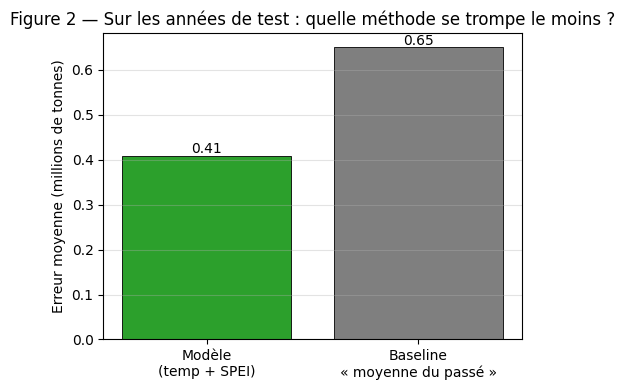

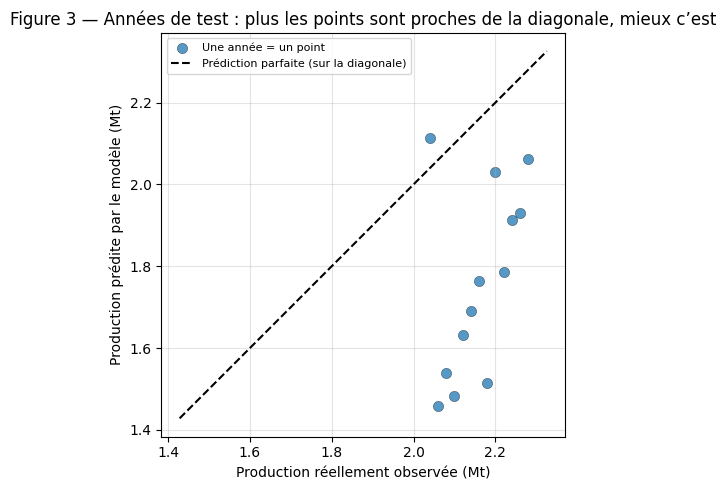

In [18]:
# --- Partie 2 ---

prod = pd.read_csv(PROD_PATH, comment="#")
prod = prod.loc[
    (prod["Country"] == "USA") & (prod["Item"].str.upper() == "WHEAT"), ["Year", "Value"]
].copy()
prod = prod.rename(columns={"Value": "production_t"}).sort_values("Year").reset_index(drop=True)

spei_long = pd.read_csv(SPEI_PATH)
spei_long["Month"] = pd.to_datetime(spei_long["time"], errors="coerce").dt.to_period("M").dt.to_timestamp()
spei_long = spei_long[["Month", "spei"]].dropna(subset=["Month"]).drop_duplicates(subset=["Month"], keep="last")

clim_m = giss_monthly.merge(spei_long, on="Month", how="inner")
clim_m["cy"] = clim_m["Month"].dt.year
clim_m["mo"] = clim_m["Month"].dt.month
gs = clim_m.loc[clim_m["mo"].between(5, 9)]
yearly_c = (
    gs.groupby("cy", sort=True)
    .agg(temp_gs_mean=("temp_plains_mean", "mean"), spei_gs_mean=("spei", "mean"))
    .reset_index()
)

# Météo (mai–sep année K) -> production année K+1
weather = yearly_c.rename(columns={"cy": "weather_year"}).copy()
weather["Year"] = weather["weather_year"] + 1
weather = weather[["Year", "temp_gs_mean", "spei_gs_mean"]]

pan = prod.merge(weather, on="Year", how="inner").dropna()
print("Panel annuel (production × climat lag) :", pan.shape)
print("Années :", pan["Year"].min(), "→", pan["Year"].max())
print(pan.head(3).to_string())
print("…")
print(pan.tail(3).to_string())

r_tp = pan["temp_gs_mean"].corr(pan["production_t"])
r_sp = pan["spei_gs_mean"].corr(pan["production_t"])
print("\n--- Associations sur tout l’historique (indicateur de tendance commune, pas de causalité) ---")
print(f"Température (mai–sep, année précédente) vs production : coefficient r = {r_tp:.2f}")
print(f"  → en langage simple : alignement « en ligne droite » ≈ {abs(r_tp) * 100:.0f} % du maximum possible (100 % = points sur une droite parfaite).")
print(f"SPEI vs production : r = {r_sp:.2f}  → ≈ {abs(r_sp) * 100:.0f} % du maximum (même lecture).")

pan["production_mt"] = pan["production_t"] / 1e6  # millions de tonnes, plus lisible sur les axes


def _line(x, y, ax, color="C0"):
    xl, xr = np.nanmin(x), np.nanmax(x)
    if np.isfinite(xl) and np.isfinite(xr) and float(xr - xl) > 0:
        z = np.polyfit(x, y, 1)
        xs = np.linspace(float(xl), float(xr), 50)
        ax.plot(xs, np.poly1d(z)(xs), color=color, lw=2.5, label="Tendance (ligne la plus proche des points)")
    ax.legend(loc="best", fontsize=8)


fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(pan["temp_gs_mean"], pan["production_mt"], alpha=0.65, s=40, edgecolors="k", linewidths=0.2)
_line(pan["temp_gs_mean"].values, pan["production_mt"].values, ax[0], "C0")
ax[0].set_xlabel("Anomalie de température (Plaines, moy. mai–sep, année d’avant)")
ax[0].set_ylabel("Production de blé USA (millions de tonnes)")
ax[0].set_title("Température vs production")
ax[0].grid(True, alpha=0.35)

ax[1].scatter(pan["spei_gs_mean"], pan["production_mt"], alpha=0.65, s=40, color="tab:green", edgecolors="k", linewidths=0.2)
_line(pan["spei_gs_mean"].values, pan["production_mt"].values, ax[1], "tab:green")
ax[1].set_xlabel("Indice SPEI (humidité / sécheresse, moy. mai–sep, année d’avant)")
ax[1].set_ylabel("Production de blé USA (millions de tonnes)")
ax[1].set_title("SPEI vs production (plus bas = plus sec, en général)")
ax[1].grid(True, alpha=0.35)

plt.suptitle("Figure 1 — Production annuelle vs climat (toutes les années disponibles)", y=1.05, fontsize=11)
plt.tight_layout()
plt.show()

feat2 = ["temp_gs_mean", "spei_gs_mean"]
X2 = pan[feat2]
y2 = pan["production_t"].astype(float)
split2 = int(len(pan) * 0.8)
X_tr2, X_te2 = X2.iloc[:split2], X2.iloc[split2:]
y_tr2, y_te2 = y2.iloc[:split2], y2.iloc[split2:]
years_te2 = pan["Year"].iloc[split2:]

n_tot = len(pan)
pct_train = 100 * split2 / n_tot
pct_test = 100 * (n_tot - split2) / n_tot
print(f"\n--- Découpage temporel (comme un « examen sur le futur ») ---")
print(
    f"Années pour construire le modèle : {split2} ({pct_train:.0f} % du tableau), "
    f"période de test : {n_tot - split2} années ({pct_test:.0f} %), "
    f"soit {years_te2.min():.0f}–{years_te2.max():.0f}."
)

reg_p = LinearRegression().fit(X_tr2, y_tr2)
pred_p = reg_p.predict(X_te2)
base_pred_p = np.full_like(pred_p, fill_value=float(y_tr2.mean()), dtype=float)

r2_m = r2_score(y_te2, pred_p)
r2_b = r2_score(y_te2, base_pred_p)
mae_m = mean_absolute_error(y_te2, pred_p)
mae_b = mean_absolute_error(y_te2, base_pred_p)
mean_te = float(y_te2.mean())

print("\n--- Erreur moyenne sur la période de test (en tonnes puis en %) ---")
print(f"Avec température + SPEI : erreur moyenne = {mae_m:,.0f} t ")
print(f"  → soit ≈ {100 * mae_m / mean_te:.1f} % de la production moyenne observée sur le test.")
print(f'Sans climat (scénario « on prédit toujours la moyenne du passé ») : {mae_b:,.0f} t ')
print(f"  → soit ≈ {100 * mae_b / mean_te:.1f} % de cette production moyenne.")
if mae_b > 1e-6:
    gain = 100 * (mae_b - mae_m) / mae_b
    print(f"\n→ Le modèle climat réduit l’erreur d’environ {gain:.1f} % par rapport au scénario sans climat (sur ce test).")

print("\n--- Indicateurs techniques (option lecture rapport) ---")
print(f"R² test (modèle)     : {r2_m:.2f}  (≤ 1 ; un R² négatif = moins bon qu’une simple ligne de tendance sur le test)")
print(f"R² test (baseline)   : {r2_b:.2f}")
print("Coefficients (tonnes par unité de temp / SPEI) :", dict(zip(feat2, reg_p.coef_)))

# Figure 2 — erreurs comparées (grand public)
fig2, axb = plt.subplots(figsize=(5, 4))
labels = ["Modèle\n(temp + SPEI)", 'Baseline\n« moyenne du passé »']
vals = [mae_m / 1e6, mae_b / 1e6]
colors = ["#2ca02c", "#7f7f7f"]
bars = axb.bar(labels, vals, color=colors, edgecolor="k", linewidth=0.6)
axb.set_ylabel("Erreur moyenne (millions de tonnes)")
axb.set_title("Figure 2 — Sur les années de test : quelle méthode se trompe le moins ?")
for b, v in zip(bars, vals):
    axb.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01 * max(vals), f"{v:.2f}", ha="center", fontsize=10)
axb.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.show()

# Figure 3 — observé vs prédit (test)
y_te_mt = y_te2.values / 1e6
pred_mt = pred_p / 1e6
fig3, ax3 = plt.subplots(figsize=(5.5, 5))
lo = min(y_te_mt.min(), pred_mt.min()) * 0.98
hi = max(y_te_mt.max(), pred_mt.max()) * 1.02
ax3.scatter(y_te_mt, pred_mt, s=55, alpha=0.75, edgecolors="k", linewidths=0.3, label="Une année = un point")
ax3.plot([lo, hi], [lo, hi], "k--", lw=1.5, label="Prédiction parfaite (sur la diagonale)")
ax3.set_xlabel("Production réellement observée (Mt)")
ax3.set_ylabel("Production prédite par le modèle (Mt)")
ax3.set_title("Figure 3 — Années de test : plus les points sont proches de la diagonale, mieux c’est")
ax3.legend(loc="upper left", fontsize=8)
ax3.set_aspect("equal", adjustable="box")
ax3.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

### Partie 2 — production annuelle et signal thermique (double échelle)

**Production** blé USA (Mt, gauche) et **moyenne estivale** d’anomalie GISS Plaines (mai–sep, année précédente la récolte — comme dans le panel `pan`), en fonction de l’**année de récolte** `Year`.

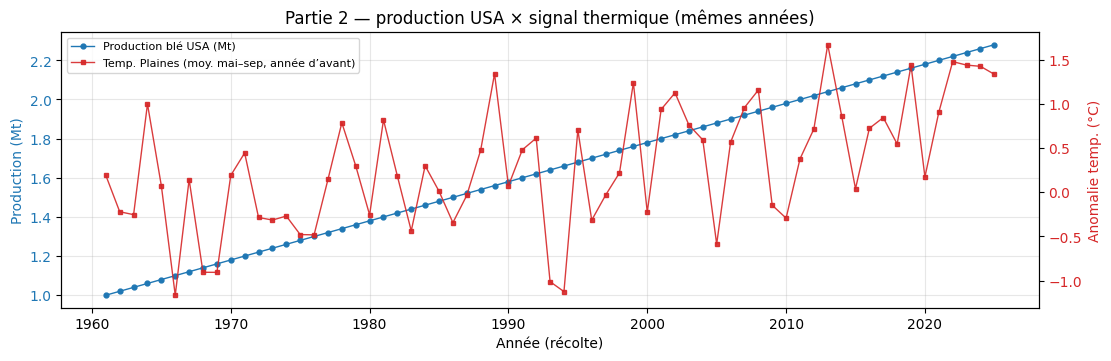

In [19]:
try:
    _ = pan.shape
except NameError as e:
    raise RuntimeError("Exécuter d'abord la cellule Partie 2 qui construit pan.") from e

fig, ax_l = plt.subplots(figsize=(11, 3.5), layout="constrained")
ax_r = ax_l.twinx()
ax_l.plot(
    pan["Year"],
    pan["production_mt"],
    color="#1f77b4",
    lw=1.0,
    marker="o",
    markersize=3.5,
    label="Production blé USA (Mt)",
)
ax_r.plot(
    pan["Year"],
    pan["temp_gs_mean"],
    color="#d62728",
    lw=1.0,
    marker="s",
    markersize=3,
    alpha=0.9,
    label="Temp. Plaines (moy. mai–sep, année d’avant)",
)
ax_l.set_xlabel("Année (récolte)")
ax_l.set_ylabel("Production (Mt)", color="#1f77b4")
ax_r.set_ylabel("Anomalie temp. (°C)", color="#d62728")
ax_l.tick_params(axis="y", labelcolor="#1f77b4")
ax_r.tick_params(axis="y", labelcolor="#d62728")
ax_l.set_title("Partie 2 — production USA × signal thermique (mêmes années)")
lines_l, lab_l = ax_l.get_legend_handles_labels()
lines_r, lab_r = ax_r.get_legend_handles_labels()
ax_l.legend(lines_l + lines_r, lab_l + lab_r, loc="upper left", fontsize=8)
ax_l.grid(True, alpha=0.3)
plt.show()

### Partie 2 — graphique des résultats (hausse / baisse de la production)

**Objectif :** même lecture que Partie 1 (barres accuracy / F1), sur données **annuelles**. Cible : **production en hausse** par rapport à l’année précédente (`production_t > production_{t-1}`). **Baseline** : **température** (mai–sep, année d’avant) seule ; **enrichi** : température **+ SPEI**. Split chronologique **80/20** sur les années ordonnées.

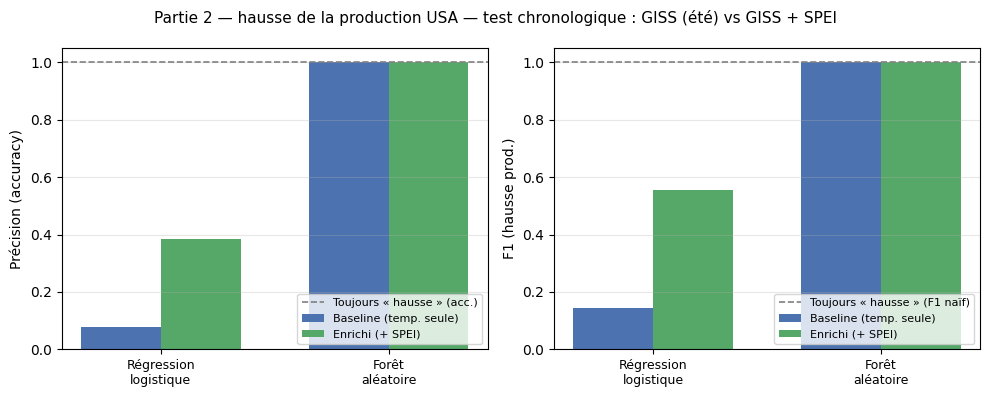

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    _ = pan.shape
except NameError as e:
    raise RuntimeError("Exécuter d'abord la cellule Partie 2 qui construit pan.") from e

pan_c = pan.sort_values("Year").reset_index(drop=True).copy()
pan_c["Target_up"] = (pan_c["production_t"] > pan_c["production_t"].shift(1)).astype(int)
pan_c = pan_c.dropna(subset=["Target_up"]).reset_index(drop=True)

split_y = int(len(pan_c) * 0.8)
feat_t2 = ["temp_gs_mean"]
feat_a2 = ["temp_gs_mean", "spei_gs_mean"]
X_tr_m = pan_c[feat_t2].iloc[:split_y]
X_te_m = pan_c[feat_t2].iloc[split_y:]
X_tr_a = pan_c[feat_a2].iloc[:split_y]
X_te_a = pan_c[feat_a2].iloc[split_y:]
y_tr = pan_c["Target_up"].iloc[:split_y]
y_te = pan_c["Target_up"].iloc[split_y:]


def make_lr2():
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=42,
                    solver="lbfgs",
                ),
            ),
        ]
    )


def make_rf2():
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )


def _test_scores2(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    if hasattr(model, "predict_proba"):
        proba1 = model.predict_proba(X_test)[:, 1]
        y_pred = (proba1 >= 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    return acc, f1


model_specs2 = [
    ("Régression logistique", make_lr2),
    ("Forêt aléatoire", make_rf2),
]
acc_b, acc_e, f1_b, f1_e = [], [], [], []
for _lab, factory in model_specs2:
    ab, fb = _test_scores2(factory(), X_tr_m, X_te_m, y_tr, y_te)
    ae, fe = _test_scores2(factory(), X_tr_a, X_te_a, y_tr, y_te)
    acc_b.append(ab)
    acc_e.append(ae)
    f1_b.append(fb)
    f1_e.append(fe)

x2 = np.arange(len(model_specs2))
width2 = 0.35
p_up_te = float(y_te.mean())
acc_nv = p_up_te
f1_nv = (2 * p_up_te / (1 + p_up_te)) if p_up_te > 0 else 0.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
cfgs = [
    (acc_b, acc_e, "Précision (accuracy)", acc_nv, "Toujours « hausse » (acc.)"),
    (f1_b, f1_e, "F1 (hausse prod.)", f1_nv, "Toujours « hausse » (F1 naïf)"),
]
for ax, (base, enr, title, ref_line, ref_label) in zip(axes, cfgs):
    ax.bar(x2 - width2 / 2, base, width2, label="Baseline (temp. seule)", color="#4C72B0")
    ax.bar(x2 + width2 / 2, enr, width2, label="Enrichi (+ SPEI)", color="#55A868")
    ax.axhline(ref_line, color="gray", linestyle="--", linewidth=1.2, label=ref_label)
    ax.set_xticks(x2)
    ax.set_xticklabels([m_[0].replace(" ", "\n") for m_ in model_specs2], fontsize=9)
    ax.set_ylabel(title)
    top = max(ref_line, *base, *enr)
    ax.set_ylim(0, min(1.05, top * 1.12 + 0.02))
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    "Partie 2 — hausse de la production USA — test chronologique : GISS (été) vs GISS + SPEI",
    fontsize=11,
)
fig.tight_layout()
plt.show()

### Partie 2.2 — **Production** blé USA ↔ **marché** (ZW=F)

**Objectif :** tester directement s’il existe une **association statistique** entre la **production annuelle** (tonnes, USA/Wheat) et le **rendement annuel du contrat** CBOT, construit en **composant** les rendements mensuels sur chaque **année civile** \((\prod_m (1+r_m)-1)\).

**Limite :** le prix futures reflète une **offre et une demande mondiales** anticipées ; la production US n’en est qu’**un** levier — une corrélation faible ou nulle est **informatif**. **Association ≠ causalité.** Prérequis : les packages de **§0** ; cette cellule relit les CSV (exécutable seule ou après Partie 1 pour cohérence).

--- Partie 2.2 — fusion annuelle (production × marché) ---
Nombre d’années jointes : 26 | période : 2000 → 2025

Corrélation Pearson (niveau production en tonnes, rendement annuel ZW=F) : -0.2400
Corrélation Pearson (variation relative annuelle de la production vs rendement marché) : 0.2362 (sur 25 années avec Δproduction disponible).
Lecture qualitative du coefficient niveau : alignement linéaire ~ 24 % du maximum possible (100 % = nuage sur une droite).


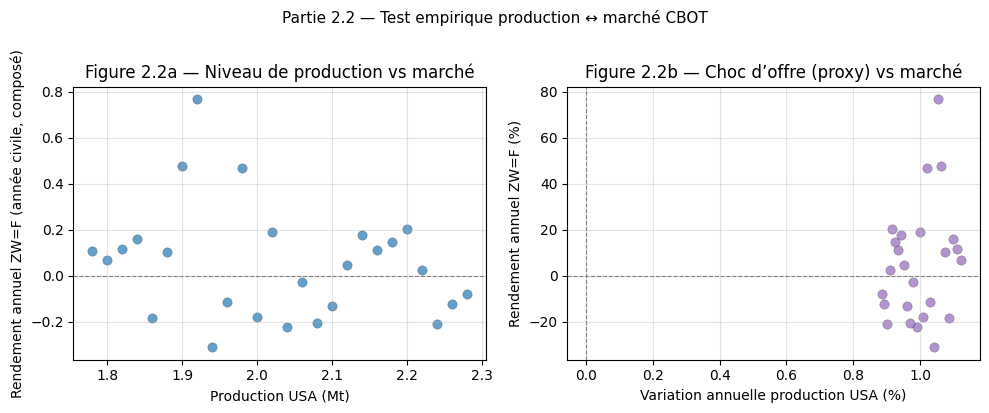


--- Mini validation chronologique (75 % / 25 %, Δproduction → rendement) ---
Pente (coef) : 106.5267  (interprétation : +1 pt de % prod → ~10652.67 pts de rendement annuel moyen du modèle)
R² test     : -0.0777
R² baseline : -0.1570
MAE test (modèle)    : 12.32 % (points de rendement)
MAE test (moy. train): 12.98 %


In [21]:
# --- Partie 2.2 — production USA × marché (rendement annuel calendaire ZW=F) ---

prod_mkt = pd.read_csv(PROD_PATH, comment="#")
prod_mkt = prod_mkt.loc[
    (prod_mkt["Country"] == "USA") & (prod_mkt["Item"].str.upper() == "WHEAT"), ["Year", "Value"]
].copy()
prod_mkt = prod_mkt.rename(columns={"Value": "production_t"}).sort_values("Year").reset_index(drop=True)

wheat_y = pd.read_csv(WHEAT_PATH, skiprows=[1])
wheat_y["Date"] = pd.to_datetime(wheat_y["Date"], errors="coerce")
wheat_y = wheat_y.dropna(subset=["Date", "Monthly_Return"])
wheat_y["Year"] = wheat_y["Date"].dt.year

def _compound_year(s: pd.Series) -> float:
    x = np.asarray(s.dropna(), dtype=float)
    if len(x) == 0:
        return np.nan
    return float(np.prod(1.0 + x) - 1.0)

yearly_mkt = (
    wheat_y.groupby("Year", sort=True)["Monthly_Return"].apply(_compound_year).rename("wheat_ret_y").reset_index()
)

pan_m = prod_mkt.merge(yearly_mkt, on="Year", how="inner").sort_values("Year").reset_index(drop=True)
pan_m["production_mt"] = pan_m["production_t"] / 1e6
pan_m["pct_change_production"] = pan_m["production_t"].pct_change()
pan_m["pct_change_production"] = pan_m["pct_change_production"].replace([np.inf, -np.inf], np.nan)

n_m = len(pan_m)
y0, y1 = int(pan_m["Year"].min()), int(pan_m["Year"].max())
print("--- Partie 2.2 — fusion annuelle (production × marché) ---")
print(f"Nombre d’années jointes : {n_m} | période : {y0} → {y1}")

r_level = pan_m["production_t"].corr(pan_m["wheat_ret_y"])
sub = pan_m.dropna(subset=["pct_change_production"])
r_growth = sub["pct_change_production"].corr(sub["wheat_ret_y"])

print("\nCorrélation Pearson (niveau production en tonnes, rendement annuel ZW=F) :", f"{r_level:.4f}")
print(
    "Corrélation Pearson (variation relative annuelle de la production vs rendement marché) :",
    f"{r_growth:.4f}",
    f"(sur {len(sub)} années avec Δproduction disponible).",
)

if n_m >= 5 and np.isfinite(r_level):
    print("Lecture qualitative du coefficient niveau : alignement linéaire ~", f"{abs(r_level) * 100:.0f} % du maximum possible (100 % = nuage sur une droite).")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(pan_m["production_mt"], pan_m["wheat_ret_y"], alpha=0.7, s=45, edgecolors="k", linewidths=0.2)
ax[0].set_xlabel("Production USA (Mt)")
ax[0].set_ylabel("Rendement annuel ZW=F (année civile, composé)")
ax[0].set_title("Figure 2.2a — Niveau de production vs marché")
ax[0].axhline(0, color="gray", lw=0.8, ls="--")
ax[0].grid(True, alpha=0.35)

if len(sub) > 2:
    ax[1].scatter(100 * sub["pct_change_production"], 100 * sub["wheat_ret_y"], alpha=0.7, s=45, color="tab:purple", edgecolors="k", linewidths=0.2)
    ax[1].set_xlabel("Variation annuelle production USA (%)")
    ax[1].set_ylabel("Rendement annuel ZW=F (%)")
    ax[1].set_title("Figure 2.2b — Choc d’offre (proxy) vs marché")
    ax[1].axhline(0, color="gray", lw=0.8, ls="--")
    ax[1].axvline(0, color="gray", lw=0.8, ls="--")
else:
    ax[1].text(0.5, 0.5, "Pas assez de points pour le panneau Δproduction.", ha="center", va="center", transform=ax[1].transAxes)
ax[1].grid(True, alpha=0.35)

plt.suptitle("Partie 2.2 — Test empirique production ↔ marché CBOT", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

# Régression simple « théorie » : plus de blé → pression baissière sur prix (signe attendu souvent négatif ; pas garanti)
if len(sub) >= 8:
    Xg = sub[["pct_change_production"]].values
    yg = sub["wheat_ret_y"].values
    split_g = int(len(sub) * 0.75)
    if split_g >= 4 and len(sub) - split_g >= 2:
        reg_g = LinearRegression().fit(Xg[:split_g], yg[:split_g])
        pred_g = reg_g.predict(Xg[split_g:])
        base_g = np.full_like(pred_g, fill_value=float(np.mean(yg[:split_g])))
        print("\n--- Mini validation chronologique (75 % / 25 %, Δproduction → rendement) ---")
        print(f"Pente (coef) : {reg_g.coef_[0]:.4f}  (interprétation : +1 pt de % prod → ~{reg_g.coef_[0]*100:.2f} pts de rendement annuel moyen du modèle)")
        print(f"R² test     : {r2_score(yg[split_g:], pred_g):.4f}")
        print(f"R² baseline : {r2_score(yg[split_g:], base_g):.4f}")
        print(f"MAE test (modèle)    : {100 * mean_absolute_error(yg[split_g:], pred_g):.2f} % (points de rendement)")
        print(f"MAE test (moy. train): {100 * mean_absolute_error(yg[split_g:], base_g):.2f} %")
else:
    print("\n(Échantillon trop court pour un split 75/25 fiable sur Δproduction — s’appuyer sur les corrélations et les graphiques.)")

### Partie 2.2 — production et rendement marché annuel (double échelle)

**Production** USA (Mt, gauche) et **rendement annuel composé** du blé ZW=F (droite), par **année civile** — même tableau que `pan_m` après la cellule ci‑dessus.

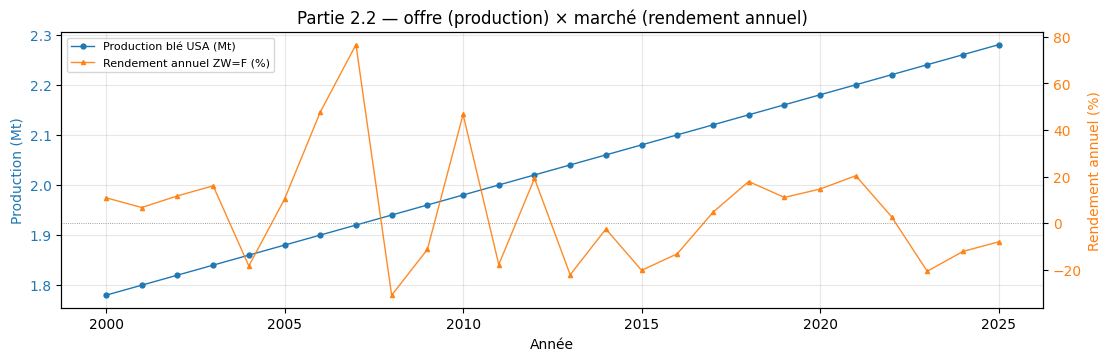

In [22]:
try:
    _ = pan_m.shape
except NameError as e:
    raise RuntimeError("Exécuter d'abord la cellule Partie 2.2 qui construit pan_m.") from e

fig, ax_l = plt.subplots(figsize=(11, 3.5), layout="constrained")
ax_r = ax_l.twinx()
ax_l.plot(
    pan_m["Year"],
    pan_m["production_mt"],
    color="#1f77b4",
    lw=1.0,
    marker="o",
    markersize=3.5,
    label="Production blé USA (Mt)",
)
ax_r.plot(
    pan_m["Year"],
    100 * pan_m["wheat_ret_y"],
    color="#ff7f0e",
    lw=1.0,
    marker="^",
    markersize=3,
    alpha=0.9,
    label="Rendement annuel ZW=F (%)",
)
ax_l.set_xlabel("Année")
ax_l.set_ylabel("Production (Mt)", color="#1f77b4")
ax_r.set_ylabel("Rendement annuel (%)", color="#ff7f0e")
ax_l.tick_params(axis="y", labelcolor="#1f77b4")
ax_r.tick_params(axis="y", labelcolor="#ff7f0e")
ax_l.set_title("Partie 2.2 — offre (production) × marché (rendement annuel)")
ax_r.axhline(0, color="gray", lw=0.6, ls=":")
lines_l, lab_l = ax_l.get_legend_handles_labels()
lines_r, lab_r = ax_r.get_legend_handles_labels()
ax_l.legend(lines_l + lines_r, lab_l + lab_r, loc="upper left", fontsize=8)
ax_l.grid(True, alpha=0.3)
plt.show()

### Partie 2.2 — graphique des résultats (année de hausse sur le marché)

Cible : **rendement annuel ZW=F > 0**. **Baseline** : **niveau** de production (Mt) seul ; **enrichi** : niveau **+ variation relative** de la production (proxy choc d’offre). Split **80/20** chronologique sur les années avec `pct_change_production` disponible.

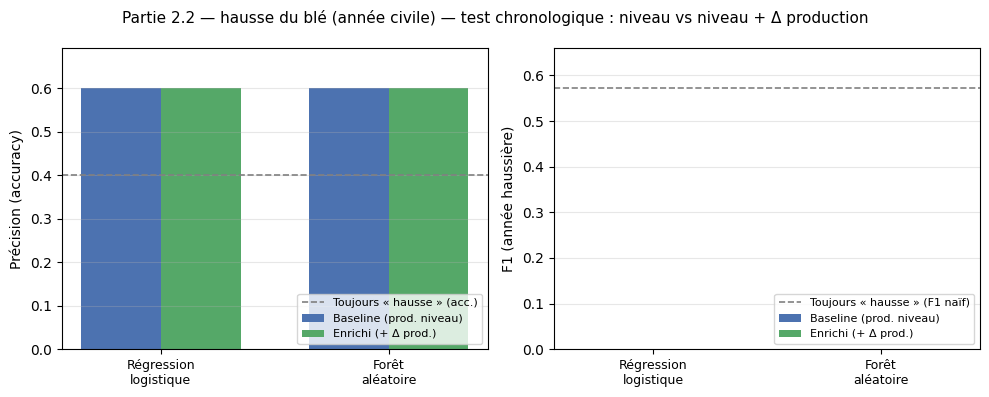

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    _ = pan_m.shape
except NameError as e:
    raise RuntimeError("Exécuter d'abord la cellule Partie 2.2 qui construit pan_m.") from e

pm = pan_m.dropna(subset=["pct_change_production"]).sort_values("Year").reset_index(drop=True)
if len(pm) < 10:
    print("Pas assez d’années avec Δproduction — graphique barres ignoré.")
else:
    pm["Target_up"] = (pm["wheat_ret_y"] > 0).astype(int)
    split_m = int(len(pm) * 0.8)
    Xb = pm[["production_mt"]]
    Xe = pm[["production_mt", "pct_change_production"]]
    X_tr_b = Xb.iloc[:split_m]
    X_te_b = Xb.iloc[split_m:]
    X_tr_e = Xe.iloc[:split_m]
    X_te_e = Xe.iloc[split_m:]
    y_tr_m = pm["Target_up"].iloc[:split_m]
    y_te_m = pm["Target_up"].iloc[split_m:]

    def make_lr_m():
        return Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "clf",
                    LogisticRegression(
                        max_iter=5000,
                        class_weight="balanced",
                        random_state=42,
                        solver="lbfgs",
                    ),
                ),
            ]
        )

    def make_rf_m():
        return RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )

    def _ts(model, Xtr, Xte, ytr, yte):
        model.fit(Xtr, ytr)
        if hasattr(model, "predict_proba"):
            p1 = model.predict_proba(Xte)[:, 1]
            yp = (p1 >= 0.5).astype(int)
        else:
            yp = model.predict(Xte)
        return accuracy_score(yte, yp), f1_score(yte, yp, pos_label=1, zero_division=0)

    specs_m = [("Régression logistique", make_lr_m), ("Forêt aléatoire", make_rf_m)]
    ab, ae, fb, fe = [], [], [], []
    for _, fac in specs_m:
        a0, f0 = _ts(fac(), X_tr_b, X_te_b, y_tr_m, y_te_m)
        a1, f1v = _ts(fac(), X_tr_e, X_te_e, y_tr_m, y_te_m)
        ab.append(a0)
        ae.append(a1)
        fb.append(f0)
        fe.append(f1v)

    xm = np.arange(len(specs_m))
    wm = 0.35
    p_up = float(y_te_m.mean())
    acc_n = p_up
    f1_n = (2 * p_up / (1 + p_up)) if p_up > 0 else 0.0

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
    cfgs_m = [
        (ab, ae, "Précision (accuracy)", acc_n, "Toujours « hausse » (acc.)"),
        (fb, fe, "F1 (année haussière)", f1_n, "Toujours « hausse » (F1 naïf)"),
    ]
    for ax, (b, e, ttl, rl, rlb) in zip(axes, cfgs_m):
        ax.bar(xm - wm / 2, b, wm, label="Baseline (prod. niveau)", color="#4C72B0")
        ax.bar(xm + wm / 2, e, wm, label="Enrichi (+ Δ prod.)", color="#55A868")
        ax.axhline(rl, color="gray", linestyle="--", linewidth=1.2, label=rlb)
        ax.set_xticks(xm)
        ax.set_xticklabels([s[0].replace(" ", "\n") for s in specs_m], fontsize=9)
        ax.set_ylabel(ttl)
        top = max(rl, *b, *e)
        ax.set_ylim(0, min(1.05, top * 1.12 + 0.02))
        ax.legend(loc="lower right", fontsize=8)
        ax.grid(axis="y", alpha=0.3)

    fig.suptitle(
        "Partie 2.2 — hausse du blé (année civile) — test chronologique : niveau vs niveau + Δ production",
        fontsize=11,
    )
    fig.tight_layout()
    plt.show()

### Synthèse — Partie 2

- **2.1 climat → production** : pour l’oral, citez les **pourcentages** (erreur vs production moyenne, **réduction d’erreur** vs baseline) et **Figures 2–3** de la cellule climat ; cohérence statistique sur longue période **sans causalité**.
- **2.2 production → marché** : corrélations **niveau** vs **Δproduction** et figures **2.2a–b** ; rappeler que le futures **ZW=F** est **mondial** et **anticipatif** — absence de lien marqué est un **résultat** possible.
- Si la **baseline** climat bat le modèle sur la MAE production, le signal météo agrégé **n’apporte pas** grand-chose sur la fenêtre de test (série **trendante** possible).
- **Association ≠ causalité** : calendriers simplifiés, SPEI USA, boîte Plain grossière, production CSV POC.

## 8. Limites — Partie 1 & 2

**Partie 1 — futures**  
1. **GISS** : anomalie, grille ~2°, boîte **Plains** = approximation.  
2. **SPEI** : **USA agrégé**.  
3. **CBOT blé** = marché **mondial** ; lien climat US souvent **faible**.  
4. **Association ≠ causalité**.

**Partie 2 — production**  
5. Série **`american_wheat_production.csv`** utilisée **telle quelle** pour le POC (non recoupée USDA ici).  
6. **Année calendaire** vs campagne marketing : convention **lag** documentée en Partie 2.  
7. **2.2 marché** : rendement **annuel** ZW=F par **composition** des mois ; lien avec la production US = **proxy** (marché **mondial**, anticipations).

---
*PFA v4 — Part 1 & 2*